# Event display and directionality analysis

This notebook, along with the ProcessNoise notebook and the EventDisplay.py files allow the visual representation of single acoustic events generated in JPP, as well as statistical analysis on the directionality, number of hits and geometrical spread of (detected) events.

This software was developed alongside the JPP implementation of JASPER (J Acoustic Simulation Package for Event Reconstruction). Due to this, there are some specific requirements for this notebook and the .py files to work.

## Set-up and required packages
The following python packages (outside of the standard ones) are required:
- ROOT
- plotly
- subprocess

For the full code to work, this notebook should be ran in an environment/container where JPP is also active. In order to check this please run the following cell. It should print the help overview for JPrint1D:



In [ ]:
!JPrint -h

## Preparing the required data files
The datasets generated by EventDisplay.py combine and therefore require information on all aspects of the acoustic simulation. For the basic functionality, one needs:
- **detector.datx** (generated from JDetector)
- **hitfile.root**  (generated from JAcouSignalGen or JAcouNoiseGen)

In order to evaluate the detection efficiency and the directionality aspects, two more files are required:
- **triggerfile.root** (generated from JAcouEventFilter, for which the input is hitfile.root)
- **displayfile.root** (generated from JAcouEventExport, for which the input is triggerfile.root)

This last file requires some further explanation. The JPP-specific ROOT datastructures are not supported by pythons ROOT. Therefore this Cpp script expands the JPP datastructure into a new file, which is readable by Python


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ROOT
# from AcousticsDataset import *
from EventDisplay import *

import sys
sys.path.append("../..")
import report_plotstyle

import os

## hitfile only demo

In [ ]:
directory_base  = '/path/to/data/dir'

detector        = os.path.join(directory_base, 'detector.datx')
hitfile         = os.path.join(directory_base, 'hits.root')

x_demo          = AcousticsDataset(detector, hitfile, 1)


Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt


In [ ]:
x_demo.plot_event()

Plotting event ID 470 at position (1844, 1390, 3068) with direction (0.451, 0.834, -0.317) at t = 4700000000 $\mu$s


# detected event

In [ ]:
directory_base  = '.'

detector        = os.path.join(directory_base, 'detector_example.root')
hitfile         = os.path.join(directory_base, 'hitfile_example_1e11GeV.root')
triggerfile     = os.path.join(directory_base, 'triggerfile_example_1e11GeV.root')
displayfile     = os.path.join(directory_base, 'displayfile_example_1e11GeV.root')

x_demo_det      = AcousticsDataset(detector, hitfile, 1, triggerfile, displayfile)


Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt


Warning in <TClass::Init>: no dictionary for class JACOUSTICDETECTOR::JAcouEvent is available
Warning in <TClass::Init>: no dictionary for class JIO::JSerialisable is available
Warning in <TClass::Init>: no dictionary for class JACOUSTICS::JCounter is available
Warning in <TClass::Init>: no dictionary for class JACOUSTICDETECTOR::JAcouTransmission is available


In [ ]:
x_demo_det.plot_detected_event()

Plotting event ID 169 at position (-826, 202, 1682) with direction (0.789, -0.412, -0.455)
324 out of 7439 used in JBillabong: 4.4%


# Read signal file
AcoustcsDataset tries to run certain JAcoustics routines to get the information from the detector file. If there is a corresponding detector file in `./<DetectorName>/dom_dict_export.txt`, it will use that instead, such that functionality without access to JPP is possible.

In [ ]:
# New approach: mention specific!
directory_base  = '.'

detector        = os.path.join(directory_base, 'detector_example.root')
hitfile         = os.path.join(directory_base, 'hitfile_example_1e11GeV.root')
triggerfile     = os.path.join(directory_base, 'triggerfile_example_1e11GeV.root')
displayfile     = os.path.join(directory_base, 'displayfile_example_1e11GeV.root')

x = AcousticsDataset(detector, hitfile, 1, triggerfile, displayfile)


In [ ]:
x.plot_what_hydrophones_are_used()

# In a histogram as a function of the floor number

In [ ]:

used_HydrophoneIDs = np.array(list(x.used_hydro_hist.keys()))

zs    = np.array([x.hydrophone_dict[hydrophoneid] for hydrophoneid in x.used_hydro_hist])[:,2]
vals  = np.array([x.used_hydro_hist[hydrophoneid] for hydrophoneid in used_HydrophoneIDs])

# Find unique z values and sum frequencies per z
unique_z, summed_f = np.unique(zs, return_inverse=True)[0], None

# Cleaner: use bincount
unique_z_vals = np.unique(zs)
# Map each z to an index
z_to_idx = {val: i for i, val in enumerate(unique_z_vals)}
indices = np.array([z_to_idx[val] for val in zs])
summed_f = np.bincount(indices, weights=vals)

# Plot
plt.figure()
plt.bar(unique_z_vals, summed_f, width=unique_z_vals[1]-unique_z_vals[0])
plt.xlabel("z [m]")
plt.ylabel("# used in detection")
plt.show()




# Angular dependency
## SINGLE FILE

In [ ]:
directory_base  = '.'

detector        = os.path.join(directory_base, 'detector_example.root')
hitfile         = os.path.join(directory_base, 'hitfile_example_1e11GeV.root')
triggerfile     = os.path.join(directory_base, 'triggerfile_example_1e11GeV.root')
displayfile     = os.path.join(directory_base, 'displayfile_example_1e11GeV.root')

x     = AcousticsDataset(detector, hitfile, 1, triggerfile, displayfile)

In [ ]:
zenitsh_dir         = x.compute_detected_directions()
zenitsh_gen_dir     = x.compute_generated_directions()

plt.figure()
plt.hist(zenitsh_gen_dir, bins=10, alpha=0.6, label="generated")
plt.hist(zenitsh_dir,     bins=10, alpha=0.6, label="detected")
plt.xlabel(r"$\cos(\theta)$")
plt.xlim(-1, 0)
plt.title("Directional")
plt.legend()

plt.tight_layout()
plt.show()



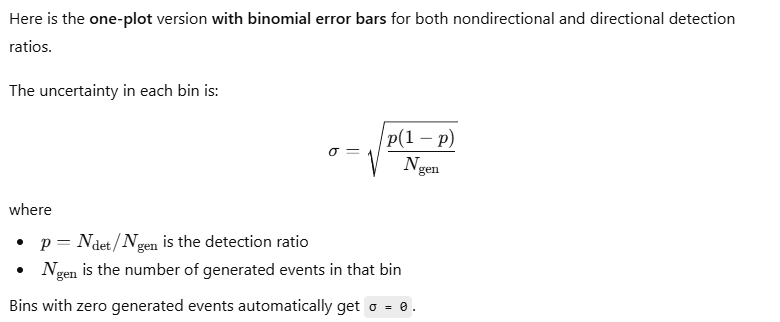

In [ ]:
zeniths_dir          = x.compute_detected_directions()
zeniths_gen_dir      = x.compute_generated_directions()

bins = 30

gen_dir_counts, bin_edges2 = np.histogram(zeniths_gen_dir, bins=bins)
det_dir_counts, _          = np.histogram(zeniths_dir,     bins=bin_edges2)

# --- Ratio ---
ratio_dir = np.divide(det_dir_counts, gen_dir_counts,
                      out=np.zeros_like(det_dir_counts, dtype=float),
                      where=gen_dir_counts != 0)

# --- Binomial uncertainties ---
err_dir = np.sqrt(ratio_dir * (1 - ratio_dir) / gen_dir_counts,
                  where=gen_dir_counts != 0,
                  out=np.zeros_like(ratio_dir))

# --- Bin centers ---
centers_dir    = 0.5 * (bin_edges2[:-1] + bin_edges2[1:])

# --- Plot ---
plt.figure(figsize=(7, 5))

plt.errorbar(centers_dir, ratio_dir, yerr=err_dir,
             fmt="s-", capsize=3, label="Directional")
plt.ylim(0, 1)
plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Detection ratio")
plt.title("Detection Ratio vs Zenith Angle (with binomial errors)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ANGULAR Statistics over all energies
The following cells provide an example implementation of a loop over multiple energies

In [ ]:
directory_base  = '/path/to/multiple/energy/files'
detector        = os.path.join(directory_base, 'detector.datx')

evtsdir         = os.path.join(directory_base,  'events/')

# ALL ENERGIES
# The number of events used per energy might differ
nrgies            = ['5e9',   '1e10',  '2e10',  '3e10',  '4e10',  '5e10',  '7e10',  '9e10',  '1e11',  '3e11',  '5e11',  '1e12']
nevents           = ['10000', '10000', '10000', '10000', '10000', '10000', '10000', '10000', '10000', '10000', '10000', '1000']


In [ ]:
# THIS CELL TAKES > 15 min! (for all energies)

zeniths         = np.array([])
zeniths_gen     = np.array([])

for i, E_GEV in enumerate(nrgies):
  print(f"Computing for E = {E_GEV}")
  hitfile         = os.path.join(evtsdir, 'signalMT_' + E_GEV + '_' + nevents[i] + 'events.root')
  triggerfile     = os.path.join(evtsdir, 'signalMT_trigger_' + E_GEV + '_' + nevents[i] + 'events.root')
  displayfile     = os.path.join(evtsdir, 'signalMT_display_' + E_GEV + '_' + nevents[i] + 'events.root')
  x               = AcousticsDataset(detector, hitfile, 0, triggerfile, displayfile)

  zenitsh_dir     = x.compute_detected_directions()
  zenitsh_gen_dir = x.compute_generated_directions()
  zeniths         = np.append(zeniths, zenitsh_dir)
  zeniths_gen     = np.append(zeniths_gen, zenitsh_gen_dir)



### Only detected events

In [ ]:
# # --- Left subplot: nondirectional ---
# plt.figure(figsize=(6.4,4.8))
# # plt.hist(zeniths_NH_gen, bins=10, alpha=0.6, label="generated")
# plt.hist(zeniths_NH,     bins=10, density=True,alpha=0.6, label="non-directional")
# plt.xlabel(r"$\cos(\theta)$")
# plt.ylabel("Density [-]")
# plt.xlim(-1, 0)
# # plt.hist(zeniths_gen, bins=10, alpha=0.6, label="generated")
# plt.hist(zeniths,     bins=10, density=True, alpha=0.6, label="directional")
# plt.xlabel(r"$\cos(\theta)$")
# plt.xlim(-1, 0)
# plt.legend(loc="lower left")
# plt.tight_layout()
# plt.show()


### Generated and detected events

In [ ]:
# fig, (ax1, ax2) = plt.subplots(
#     1, 2, figsize=(1.5 * 6.4, 4.8), sharey=True
# )

# # --- Left subplot: nondirectional ---
# ax1.hist(
#     zeniths_NH_gen, bins=10, alpha=0.5, 
#     edgecolor="black",
#     label="generated"
# )
# ax1.hist(
#     zeniths_NH, bins=10, alpha=0.5, 
#     edgecolor="black",
#     label="detected"
# )
# ax1.set_xlabel(r"$\cos(\theta)$")
# ax1.set_xlim(-1, 0)
# ax1.set_ylabel("Counts")
# ax1.set_title("Nondirectional")
# ax1.legend()

# # --- Right subplot: directional ---
# ax2.hist(
#     zeniths_gen, bins=10, alpha=0.5, 
#     edgecolor="black",
#     label="generated"
# )
# ax2.hist(
#     zeniths, bins=10, alpha=0.5, 
#     edgecolor="black",
#     label="detected"
# )
# ax2.set_xlabel(r"$\cos(\theta)$")
# ax2.set_xlim(-1, 0)
# ax2.set_title("Directional")
# ax2.legend()

# plt.tight_layout()
# plt.show()


In [ ]:
bins = 10
# --- Histograms ---

gen_dir_counts, bin_edges2 = np.histogram(zeniths_gen, bins=bins)
det_dir_counts, _          = np.histogram(zeniths,     bins=bin_edges2)

# --- Ratios ---
ratio_dir = np.divide(det_dir_counts, gen_dir_counts,
                      out=np.zeros_like(det_dir_counts, dtype=float),
                      where=gen_dir_counts != 0)

# --- Binomial uncertainties ---
err_dir = np.sqrt(ratio_dir * (1 - ratio_dir) / gen_dir_counts,
                  where=gen_dir_counts != 0,
                  out=np.zeros_like(ratio_dir))

# --- Bin centers ---
centers_dir    = 0.5 * (bin_edges2[:-1] + bin_edges2[1:])

# --- Angle corresponding to theta_H ---
theta_H     = 53
theta_N     = 180 - (180 - 90 - theta_H)
coszenith_H = np.cos(np.deg2rad(theta_N))

# --- Plot ---
plt.figure(figsize=(7, 5))

plt.errorbar(centers_dir, ratio_dir, yerr=err_dir,
             fmt="s-", capsize=3, label="Directional hydrophones")

# plt.ylim(0, 0.5)
plt.xlim(-1, 0)
plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Detection ratio")
# plt.axvline(coszenith_H, linestyle='--', c='k')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# What hydrophones are used (total)

In [ ]:
# tHIS CELL TAKES >10min

zs_all      = np.array([])
vals_all    = np.array([])

for i, E_GEV in enumerate(nrgies):
  print(f"Computing for E = {E_GEV}")
  # HYDRO CASE
  hitfile         = os.path.join(evtsdir, 'signalMT_' + E_GEV + '_' + nevents[i] + 'events.root')
  triggerfile     = os.path.join(evtsdir, 'signalMT_trigger_' + E_GEV + '_' + nevents[i] + 'events.root')
  displayfile     = os.path.join(evtsdir, 'signalMT_display_' + E_GEV + '_' + nevents[i] + 'events.root')
  x               = AcousticsDataset(detector, hitfile, 1, triggerfile, displayfile)
  x.correlate_events()
  x._what_hydrophones()
  
  used_HydrophoneIDs = np.array(list(x.used_hydro_hist.keys()))

  if used_HydrophoneIDs.size != 0:
    zs    = np.array([x.hydrophone_dict[hydrophoneid] for hydrophoneid in x.used_hydro_hist])[:,0]
    vals  = np.array([x.used_hydro_hist[hydrophoneid] for hydrophoneid in used_HydrophoneIDs])

    zs_all   = np.append(zs_all, zs)
    vals_all = np.append(vals_all, vals)

  # NH CASE

# Find unique z values and sum frequencies per z
unique_z, summed_f = np.unique(zs_all, return_inverse=True)[0], None

# Cleaner: use bincount
unique_z_vals = np.unique(zs_all)

# Map each z to an index
z_to_idx = {val: i for i, val in enumerate(unique_z_vals)}
indices = np.array([z_to_idx[val] for val in zs_all])
summed_f = np.bincount(indices, weights=vals_all)

Computing for E = 5e9
Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt
Correlating generated events with detected events
Correlation complete.
Computing hydrophones-used histogram
Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt
Correlating generated events with detected events
Correlation complete.
Computing hydrophones-used histogram
Computing for E = 1e10
Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt
Correlating generated events with detected events
Correlation comple

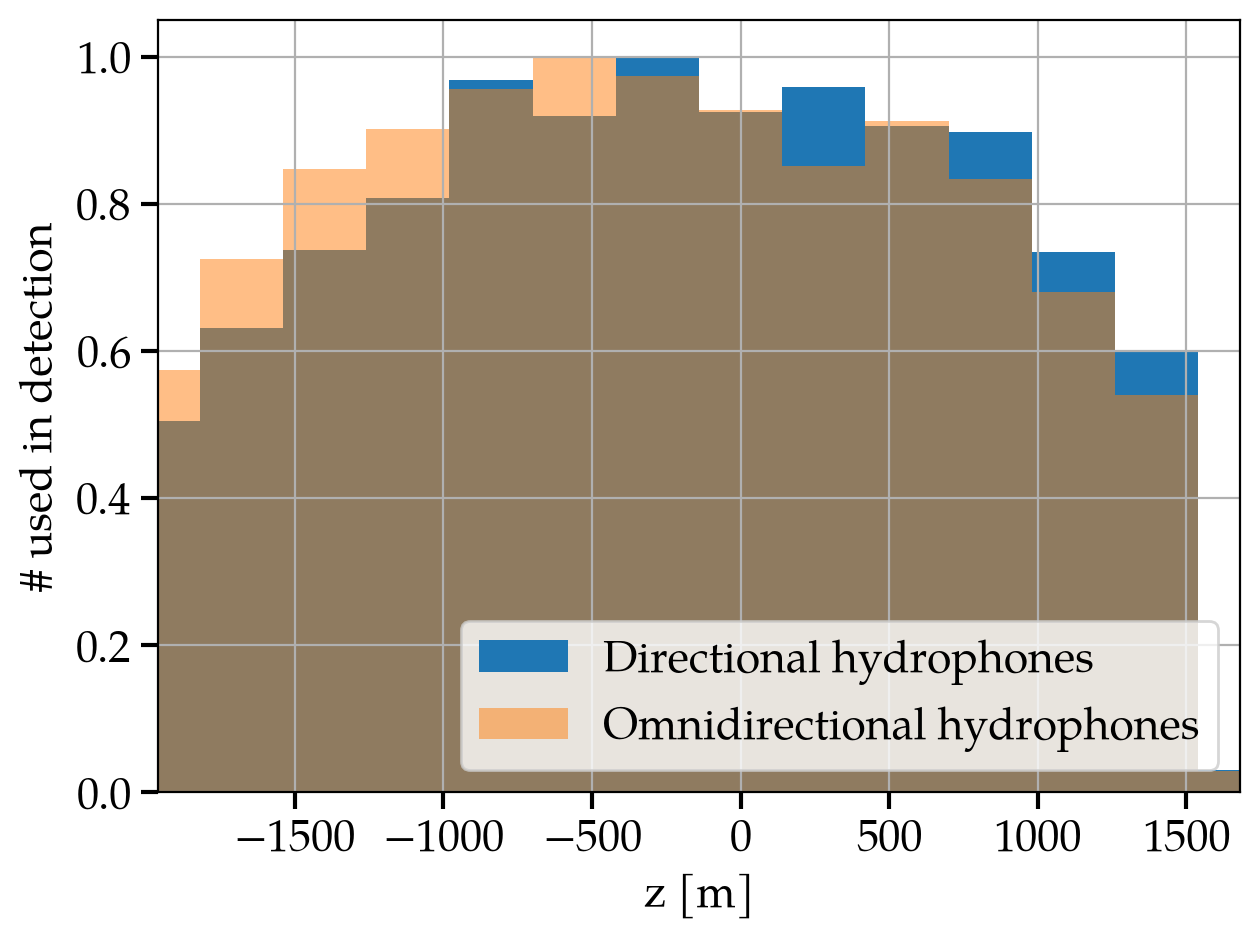

In [ ]:
# Plot
floornumbers = np.arange(75) 
plt.figure()
plt.bar(unique_z_vals, summed_f/max(summed_f), width=unique_z_vals[1]-unique_z_vals[0],label='Directional hydrophones')
plt.legend(loc='lower right')
plt.xlabel("z [m]")
plt.ylabel("# used in detection")
plt.xlim(min(unique_z_vals),max(unique_z_vals))
plt.grid(True, which='both')
plt.tight_layout()
plt.show()


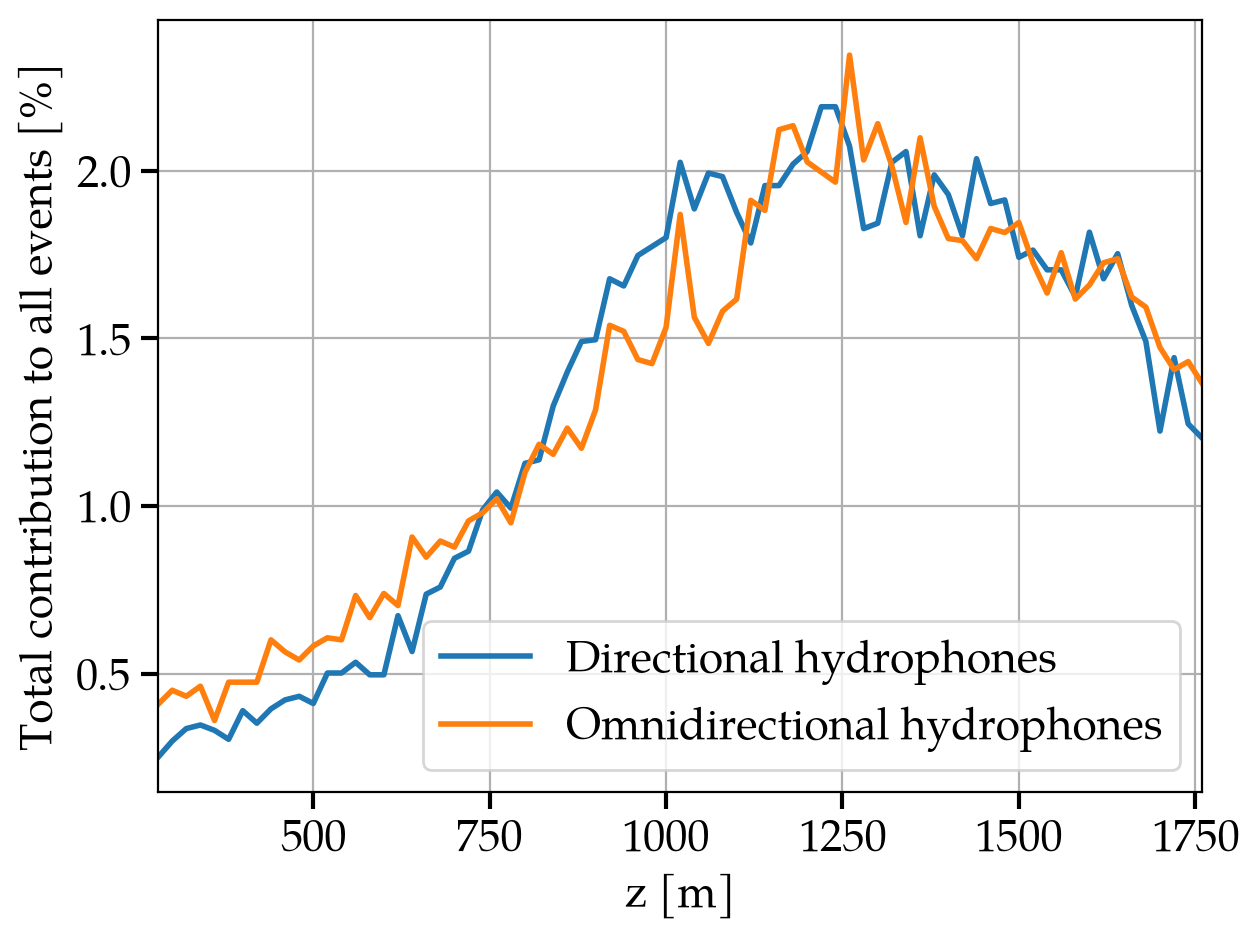

In [ ]:
# plt.figure()
# plt.bar(unique_z_vals, summed_f/sum(summed_f) * 100, width=unique_z_vals[1]-unique_z_vals[0], label='Directional hydrophones')
# plt.plot(unique_z_vals_NH, summed_f_NH/sum(summed_f_NH) * 100, color='orange', lw=2, label='Omnidirectional hydrophones')
# plt.legend(loc='lower right')
# plt.xlabel("z [m]")
# plt.ylim(0.75, 1.75)
# plt.ylabel("Total contribution to all events [%]")
# plt.xlim(min(unique_z_vals), max(unique_z_vals))
# plt.show()

plt.figure()
plt.plot(unique_z_vals,     summed_f/sum(summed_f) * 100, lw=2 , label='Directional hydrophones')
plt.legend(loc='lower right')
plt.xlabel("z [m]")
# plt.ylim(0.75, 1.75)
plt.grid(True, which='both')
plt.ylabel("Total contribution to all events [%]")
plt.xlim(min(unique_z_vals), max(unique_z_vals))
plt.tight_layout()
plt.show()

# How many events are contained?

In [ ]:
# tHIS CELL TAKES >10min

all       = np.zeros(len(nrgies))
contained = np.zeros(len(nrgies))

for i, E_GEV in enumerate(nrgies):
  print(f"Computing for E = {E_GEV}")

  hitfile         = os.path.join(evtsdir, 'signalMT_' + E_GEV + 'GeV_SS1_T7.5_' + nevents[i] + 'events.root')
  triggerfile     = os.path.join(evtsdir, 'signalMT_trigger_' + E_GEV + 'GeV_SS1_T7.5_10hits_' + nevents[i] + 'events.root')
  displayfile     = os.path.join(evtsdir, 'signalMT_display_' + E_GEV + 'GeV_SS1_T7.5_10hits_' + nevents[i] + 'events.root')
  x               = AcousticsDataset(detector, hitfile, 1, triggerfile, displayfile)

  X,Y,Z           = x.all_detected_vertices()
  all[i]          = len(X)
  cond            = (np.abs(X) < 1960) *  (np.abs(Y) < 1960) * (Z > 280) * (Z < 1760)
  contained[i]    = np.sum(cond)



Computing for E = 5e9
Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt
Correlating generated events with detected events
Correlation complete.
Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt
Correlating generated events with detected events
Correlation complete.
Computing for E = 1e10
Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt
Correlating generated events with detected events
Correlation complete.
Trying to extract DOM geometry using JPrintDetector from: /home/hbaets

In [47]:
print(sum(all_NH))

764.0


In [ ]:
ratio_dir = np.divide(contained,    all,    out=np.full_like(contained,    np.nan), where=all    != 0)

# plt.figure()
# plt.plot(np.array(nrgies).astype(float), ratio_dir, 'x',label='Directional')
# plt.plot(np.array(nrgies).astype(float), ratio_NH, 'x',label='Non-directional')
# plt.legend()
# plt.grid(True, which='both')
# plt.tight_layout()
# plt.xlabel("Energy [GeV]")
# plt.ylabel("Contained / Total")
# plt.xscale('log')

In [ ]:
# energies = np.asarray(nrgies, dtype=float)
# energies_mask = all_NH > 0


# fig, ax1 = plt.subplots()

# # --- Left y-axis ---
# ax1.plot(energies[energies_mask], ratio_dir[energies_mask], 'x-', label='Directional: Ratio')
# ax1.plot(energies[energies_mask], ratio_NH[energies_mask],  'x-', label='Omnidirectional: Ratio')

# ax1.set_xlabel("Energy [GeV]")
# ax1.set_ylabel("Contained / Total")
# ax1.set_xscale('log')
# ax1.set_xlim(1e10, 1e12)
# ax1.grid(True, which='both')

# # --- Right y-axis ---
# ax2 = ax1.twinx()

# ax2.plot(energies[energies_mask], all[energies_mask],   '--', c='purple',alpha=0.5, label="Directional: All events ")
# ax2.plot(energies[energies_mask], all_NH[energies_mask], '--',c='red', alpha=0.5, label="Omnidirectional: All events")

# ax2.set_ylabel("All detected events")
# ax2.set_yscale('log')

# # --- Legends ---
# ax1.legend(loc='lower left')
# ax2.legend(loc='upper right')
# # plt.legend(loc="lower left")
# plt.tight_layout()
# plt.show()

In [ ]:
# Compensate for factor 10 less events at 1e12
all_plot    = np.copy(all)
all_plot[-1] *= 10

from matplotlib.lines import Line2D

energies = np.asarray(nrgies, dtype=float)
energies_mask = all > 0

fig, ax1 = plt.subplots(figsize=(9,5))

# Colors per axis
c_ratio = "tab:blue"
c_all   = "tab:orange"

# --- Left y-axis: ratios ---
l1, = ax1.plot(
    energies[energies_mask],
    ratio_dir[energies_mask],
    linestyle='-',
    marker='x',
    color=c_ratio,
    label="Directional ratio"
)


ax1.set_xlabel("Energy [GeV]")
ax1.set_ylabel("Contained / Total", color=c_ratio)
ax1.tick_params(axis='y', labelcolor=c_ratio)
ax1.set_xscale('log')
ax1.set_xlim(1e10, 2e12)
ax1.grid(True, which='both')

# --- Right y-axis: all events ---
ax2 = ax1.twinx()

l3, = ax2.plot(
    energies[energies_mask],
    all_plot[energies_mask],
    linestyle='-',
    color=c_all,
    alpha=0.8,
    label="Directional all events"
)


ax2.set_ylabel("All detected events", color=c_all)
ax2.tick_params(axis='y', labelcolor=c_all)
ax2.set_yscale('log')

# --- Single combined legend ---
lines = [l1, l3]
labels = [l.get_label() for l in lines]

ax2.legend(
    lines,
    labels,
    loc="center right",
    # bbox_to_anchor=(0.5, 1.15),
    # ncol=2,
    frameon=True
)

plt.tight_layout()
plt.show()


In [ ]:
# Compensate for factor 10 less events at 1e12
all_plot    = np.copy(all)
all_plot[-1] *= 10

energies = np.asarray(nrgies, dtype=float)
energies_mask = all > 0

# Create figure with two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(6, 6)
)

# ---------- TOP: CONTAINED / TOTAL ----------
ax1.plot(
    energies[energies_mask],
    ratio_dir[energies_mask],
    linestyle=':',
    marker='x',
    label="Directional"
)

ax1.set_ylabel("Contained / Total")
ax1.set_xscale('log')
ax1.set_xlim(1e10, 2e12)
ax1.grid(True, which='both')
ax1.legend()

# ---------- BOTTOM: TOTAL EVENTS ----------
ax2.plot(
    energies[energies_mask],
    all_plot[energies_mask],
    linestyle='-',
    marker='x',
    label="Directional"
)


ax2.set_xlabel("Energy [GeV]")
ax2.set_ylabel("Number of detected events")
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(1e10, 2e12)
ax2.grid(True, which='both')
ax2.legend()

plt.tight_layout()
plt.show()


# Number of hits per event

In [ ]:
# tHIS CELL TAKES >10min

Nhits         = np.zeros(len(nrgies))
Nhits_std     = np.zeros(len(nrgies))

for i, E_GEV in enumerate(nrgies):
  print(f"Computing for E = {E_GEV}")

  hitfile         = os.path.join(evtsdir, 'signalMT_' + E_GEV + 'GeV_SS1_T7.5_' + nevents[i] + 'events.root')
  triggerfile     = os.path.join(evtsdir, 'signalMT_trigger_' + E_GEV + 'GeV_SS1_T7.5_10hits_' + nevents[i] + 'events.root')
  displayfile     = os.path.join(evtsdir, 'signalMT_display_' + E_GEV + 'GeV_SS1_T7.5_10hits_' + nevents[i] + 'events.root')
  x               = AcousticsDataset(detector, hitfile, 1, triggerfile, displayfile)

  # Beunoplossing: construeer event dict
  detected_eventdict = {}
  for entry in x.detected_tree:
    eid = int(entry.EventID) - 1

    did = int(entry.HydrophoneID)
    tid = int(entry.TemplateID)
    toa = entry.ToA
    snr = entry.SNR

    if eid not in detected_eventdict:
      detected_eventdict[eid] = [[], [], [], []]
      
    detected_eventdict[eid][0].append(did)
    detected_eventdict[eid][1].append(toa)
    detected_eventdict[eid][2].append(snr)
    detected_eventdict[eid][3].append(tid)

  Nevts = []
  for j in detected_eventdict:
    Nevts.append(len(detected_eventdict[j][0]))

  if len(Nevts) > 0:
    Nhits[i]      = np.mean(np.array(Nevts))
    Nhits_std[i]  = np.std(np.array(Nevts))
  else:
    Nhits[i]      = 0 
    Nhits_std[i]  = 0 



Computing for E = 5e9
Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt
Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt
Computing for E = 1e10
Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt
Trying to extract DOM geometry using JPrintDetector from: /home/hbaetsen/Thesis/msc-thesis-huib/cpp_detectorgen/JASPER/casestudy.datx
DOM geometry successfully extracted and saved to: ./casestudy/hydrophone_dict_export.txt
Computing for E = 2e10
Trying to extract DOM geometry using JPr

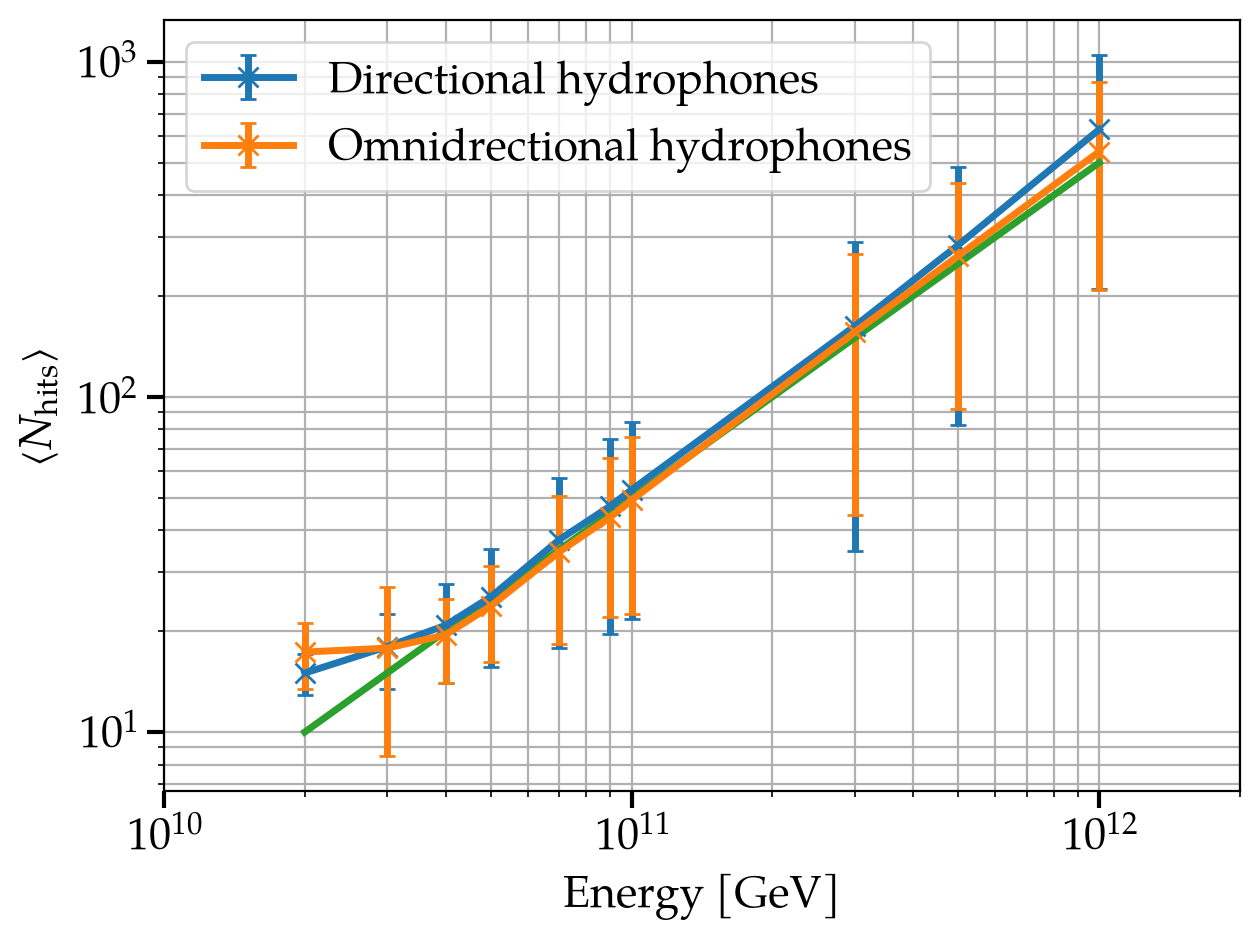

In [ ]:
energies = np.asarray(nrgies, dtype=float)
energies_mask = Nhits > 0

def f_lin(E):
  slope = (500 - 50) / (1e12 - 1e11)
  offset = 500 - slope * 1e12
  return offset + slope * E 

plt.figure()
plt.errorbar(energies[energies_mask], Nhits[energies_mask],    Nhits_std[energies_mask],    marker='x', linestyle='-', capsize=3,label= "Directional hydrophones" )
plt.plot(energies[energies_mask], f_lin(energies[energies_mask]))
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e10, 2e12)
plt.xlabel("Energy [GeV]")
plt.ylabel(r"$\langle N_{\text{hits}}\rangle$ ")
plt.legend()
plt.grid(True, which='both')
plt.tight_layout()